# MMF Stage 2: data overview

这里先确认数据格式。`speckles` 是模型看到的输出端散斑，`pattern` 是希望恢复的输入二值图案。

这里用固定光纤状态 `kappa=0` 训练 static CNN/ResNet，再单独测试 kappa 改变后的退化。

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "MMF_dataset"
if not DATA_DIR.exists():
    raise FileNotFoundError("Cannot find MMF dataset folder.")

print("data folder:", DATA_DIR.name)

data folder: MMF_dataset


In [2]:
# 先看一下数据形状，确认 speckle 和 pattern 是一一对应的
patterns = np.load(DATA_DIR / "pattern.npy", mmap_mode="r")
speckles = np.load(DATA_DIR / "speckles.npy", mmap_mode="r")
time_index = np.load(DATA_DIR / "time_index.npy", mmap_mode="r")
kappa_by_time = np.load(DATA_DIR / "kappa_by_time.npy")
counts_by_time = np.load(DATA_DIR / "counts_by_time.npy")
metadata = json.loads((DATA_DIR / "metadata.json").read_text(encoding="utf-8"))

overview = {
    "pattern_shape": list(patterns.shape),
    "speckles_shape": list(speckles.shape),
    "pattern_dtype": str(patterns.dtype),
    "speckles_dtype": str(speckles.dtype),
    "input_encoding": metadata["config"].get("input_encoding"),
    "time_states": [int(x) for x in np.unique(time_index)],
    "kappa_by_time": [float(x) for x in kappa_by_time],
    "counts_by_time": [int(x) for x in counts_by_time],
}
print(json.dumps(overview, indent=2))

{
  "pattern_shape": [
    150000,
    256
  ],
  "speckles_shape": [
    150000,
    100,
    100
  ],
  "pattern_dtype": "uint8",
  "speckles_dtype": "uint8",
  "input_encoding": "amplitude",
  "time_states": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "kappa_by_time": [
    0.0,
    0.30000001192092896,
    0.6000000238418579,
    0.8999999761581421,
    1.2000000476837158,
    1.5,
    1.7999999523162842,
    2.0999999046325684,
    2.4000000953674316,
    2.700000047683716,
    3.0
  ],
  "counts_by_time": [
    100000,
    5000,
    5000,
    5000,
    5000,
    5000,
    5000,
    5000,
    5000,
    5000,
    5000
  ]
}


In [3]:
# 随机划分固定状态样本，并检查三部分没有重叠
rng = np.random.default_rng(42)
static_ids = np.where(time_index == 0)[0].copy()
rng.shuffle(static_ids)
train_ids = static_ids[:80000]
val_ids = static_ids[80000:90000]
test_ids = static_ids[90000:100000]

leakage_check = {
    "train_samples": len(train_ids),
    "val_samples": len(val_ids),
    "test_samples": len(test_ids),
    "train_val_overlap": len(set(train_ids) & set(val_ids)),
    "train_test_overlap": len(set(train_ids) & set(test_ids)),
    "val_test_overlap": len(set(val_ids) & set(test_ids)),
}
assert leakage_check["train_val_overlap"] == 0
assert leakage_check["train_test_overlap"] == 0
assert leakage_check["val_test_overlap"] == 0
print(leakage_check)

{'train_samples': 80000, 'val_samples': 10000, 'test_samples': 10000, 'train_val_overlap': 0, 'train_test_overlap': 0, 'val_test_overlap': 0}


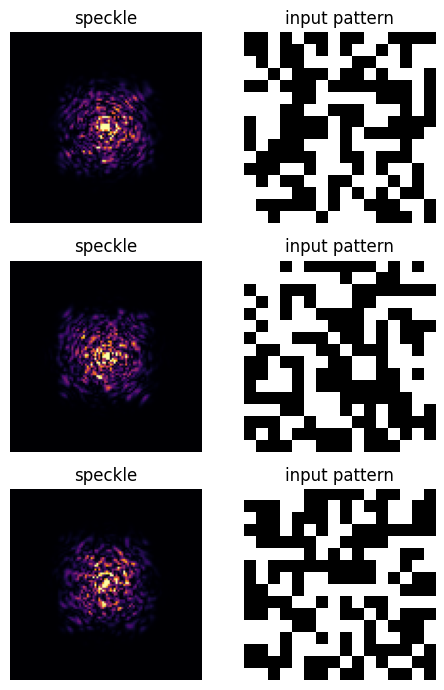

In [4]:
# 简单画几组样本，方便检查输入输出是否对应
fig, axes = plt.subplots(3, 2, figsize=(5, 7))
for row, idx in enumerate(train_ids[:3]):
    axes[row, 0].imshow(speckles[idx], cmap="inferno")
    axes[row, 0].set_title("speckle")
    axes[row, 1].imshow(patterns[idx].reshape(16, 16), cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("input pattern")
    for axis in axes[row]:
        axis.axis("off")
plt.tight_layout()
plt.show()